# Baseline Face Detection and Face Recognition Demo

This notebook walks through the complete pretrained-only pipeline: dataset download, gallery construction, embedding generation, face detection, face recognition, unknown-face handling, output saving, and final visualization.

In [1]:
# 2. Import required modules and configure output paths
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib'))

import matplotlib.pyplot as plt
import cv2

from build_gallery import build_gallery_embeddings
from src.dataset_manager import LFWDatasetManager
from src.detector import FaceDetector
from src.recognizer import FaceRecognizer
from src.utils import GALLERY_DIR, OUTPUTS_DIR, TEST_IMAGES_DIR, ensure_dir, iter_image_files, read_image
from src.visualization import draw_results, save_annotated

ensure_dir(OUTPUTS_DIR)
threshold = 0.35

In [2]:
# 3. Download dataset and create the automatic split
manager = LFWDatasetManager()
manifest = manager.prepare_splits()
manifest.stats

{'raw_images': 13233,
 'eligible_identities': 62,
 'selected_identities': 10,
 'unknown_identities': 3,
 'gallery_images': 150,
 'known_test_images': 50,
 'unknown_test_images': 20}

In [3]:
# 4. Build gallery embeddings
metadata = build_gallery_embeddings(GALLERY_DIR, Path('embeddings'))
len(metadata)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


...

Building tony_blair:  80%|████████  | 12/15 [00:13<00:03,  1.09s/it]

Building tony_blair:  87%|████████▋ | 13/15 [00:14<00:02,  1.16s/it]

Building tony_blair:  93%|█████████▎| 14/15 [00:15<00:01,  1.13s/it]

Building tony_blair: 100%|██████████| 15/15 [00:16<00:00,  1.24s/it]

10

In [4]:
# 5. Detect faces in a known sample image
detector = FaceDetector()
known_images = iter_image_files(TEST_IMAGES_DIR / 'known')
sample_known = known_images[0]
image = read_image(sample_known)
faces = detector.detect(image)
len(faces)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


1

In [5]:
# 6. Recognize faces in a known sample image
recognizer = FaceRecognizer(Path('embeddings'), threshold=0.35)
_, results = recognizer.recognize_image(image)
annotated_known = draw_results(image, results, 0.35)
known_output_path = OUTPUTS_DIR / f'{sample_known.stem}_demo.jpg'
save_annotated(annotated_known, known_output_path)
[(result.identity, result.similarity) for result in results]

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


[('ariel_sharon', 0.907382607460022)]

In [6]:
# 7. Evaluate an unknown sample
unknown_images = iter_image_files(TEST_IMAGES_DIR / 'unknown')
sample_unknown = unknown_images[0]
unknown_image = read_image(sample_unknown)
_, unknown_results = recognizer.recognize_image(unknown_image)
annotated_unknown = draw_results(unknown_image, unknown_results, threshold)
unknown_output_path = OUTPUTS_DIR / f'{sample_unknown.stem}_unknown_demo.jpg'
save_annotated(annotated_unknown, unknown_output_path)
[(result.identity, result.similarity) for result in unknown_results]

[('UNKNOWN', 0.10105899721384048)]

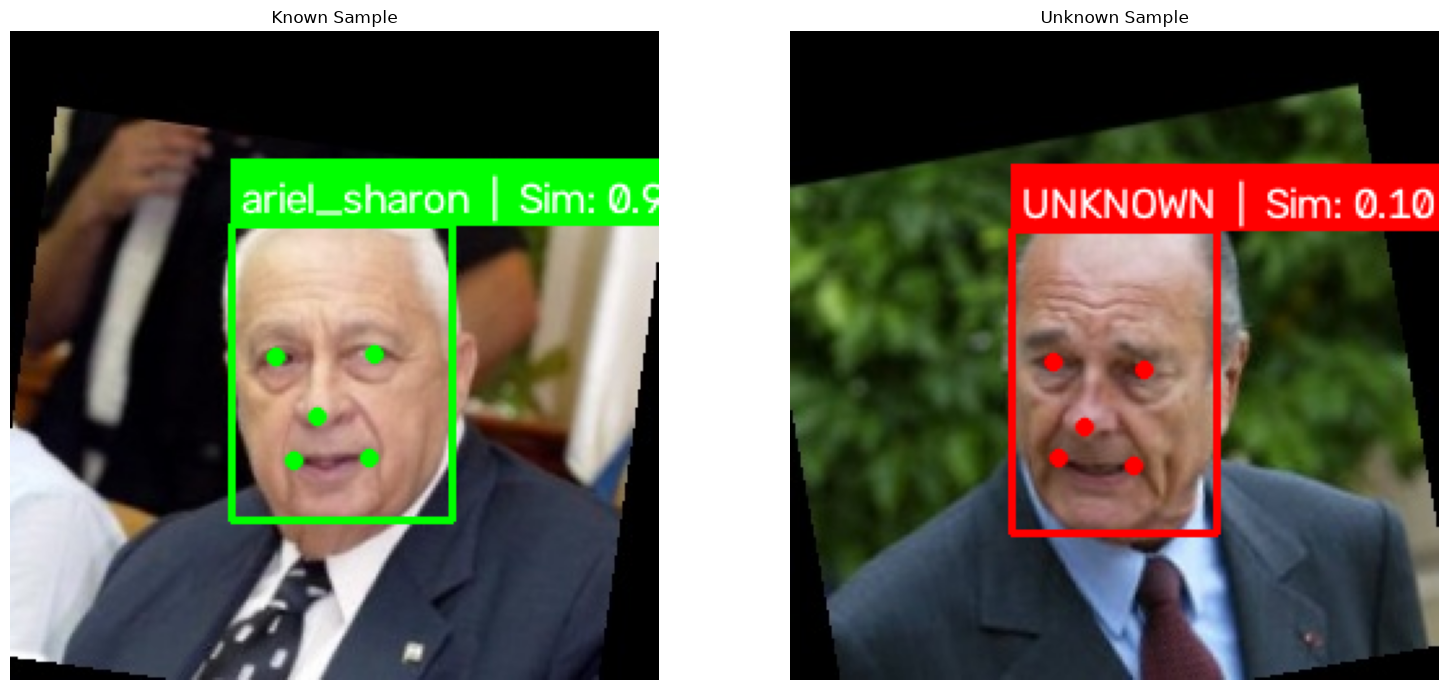

In [7]:
# 8. Display final results
import matplotlib.pyplot as plt
import cv2

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(cv2.cvtColor(annotated_known, cv2.COLOR_BGR2RGB))
axes[0].set_title('Known Sample')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated_unknown, cv2.COLOR_BGR2RGB))
axes[1].set_title('Unknown Sample')
axes[1].axis('off')
plt.tight_layout()

## Research Evaluation and Reporting

The following cells generate gallery statistics, performance metrics, threshold experiments, and the confusion matrix used in the presentation.

In [8]:
from src.reporting import gallery_statistics, save_gallery_report
gallery_statistics()

{'number_of_identities': 10,
 'images_per_identity': {'ariel_sharon': 15,
  'colin_powell': 15,
  'donald_rumsfeld': 15,
  'george_w_bush': 15,
  'gerhard_schroeder': 15,
  'hugo_chavez': 15,
  'jean_chretien': 15,
  'john_ashcroft': 15,
  'junichiro_koizumi': 15,
  'tony_blair': 15},
 'embedding_dimension': 512,
 'total_gallery_images': 150}

In [9]:
from evaluate_thresholds import run_evaluation
threshold_results = run_evaluation()
threshold_results

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


find model: C:\Users\hp\Desktop\FaceRecognition_Baseline\.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


[{'threshold': 0.2,
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1_score': 1.0,
  'false_positive_rate': 0.0,
  'false_negative_rate': 0.0},
 {'threshold': 0.25,
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1_score': 1.0,
  'false_positive_rate': 0.0,
  'false_negative_rate': 0.0},
 {'threshold': 0.3,
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1_score': 1.0,
  'false_positive_rate': 0.0,
  'false_negative_rate': 0.0},
 {'threshold': 0.35,
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1_score': 1.0,
  'false_positive_rate': 0.0,
  'false_negative_rate': 0.0},
 {'threshold': 0.4,
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1_score': 1.0,
  'false_positive_rate': 0.0,
  'false_negative_rate': 0.0},
 {'threshold': 0.45,
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1_score': 1.0,
  'false_positive_rate': 0.0,
  'false_negative_rate': 0.0},
 {'threshold': 0.5,
  'accuracy': 1.0,
  'precision': 1.0,
  

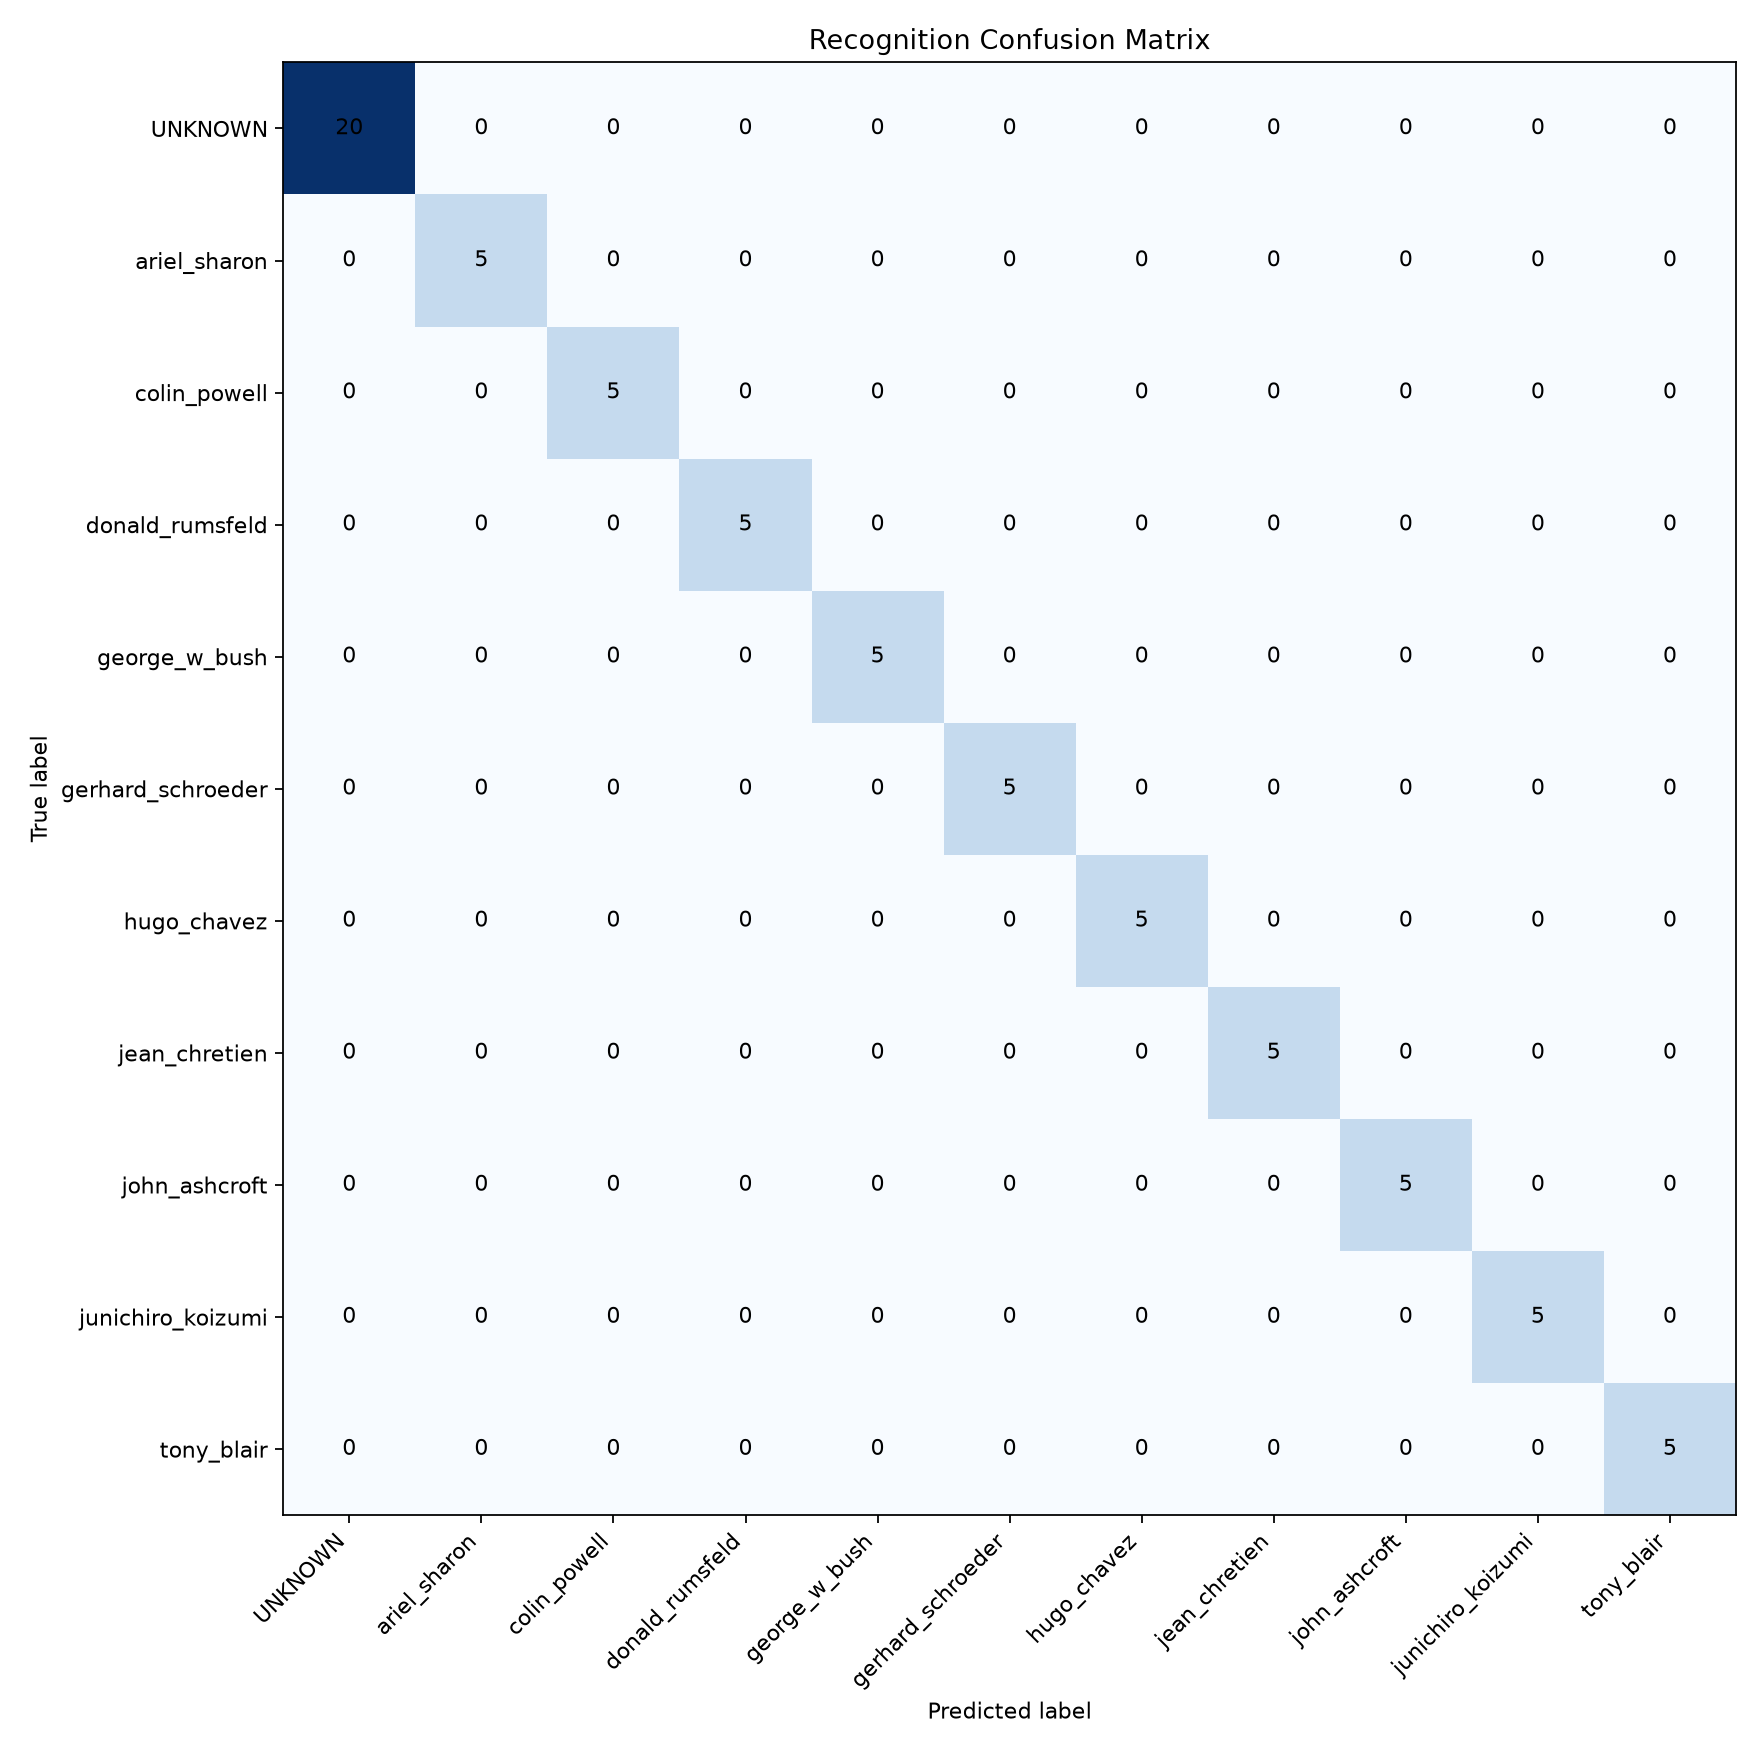

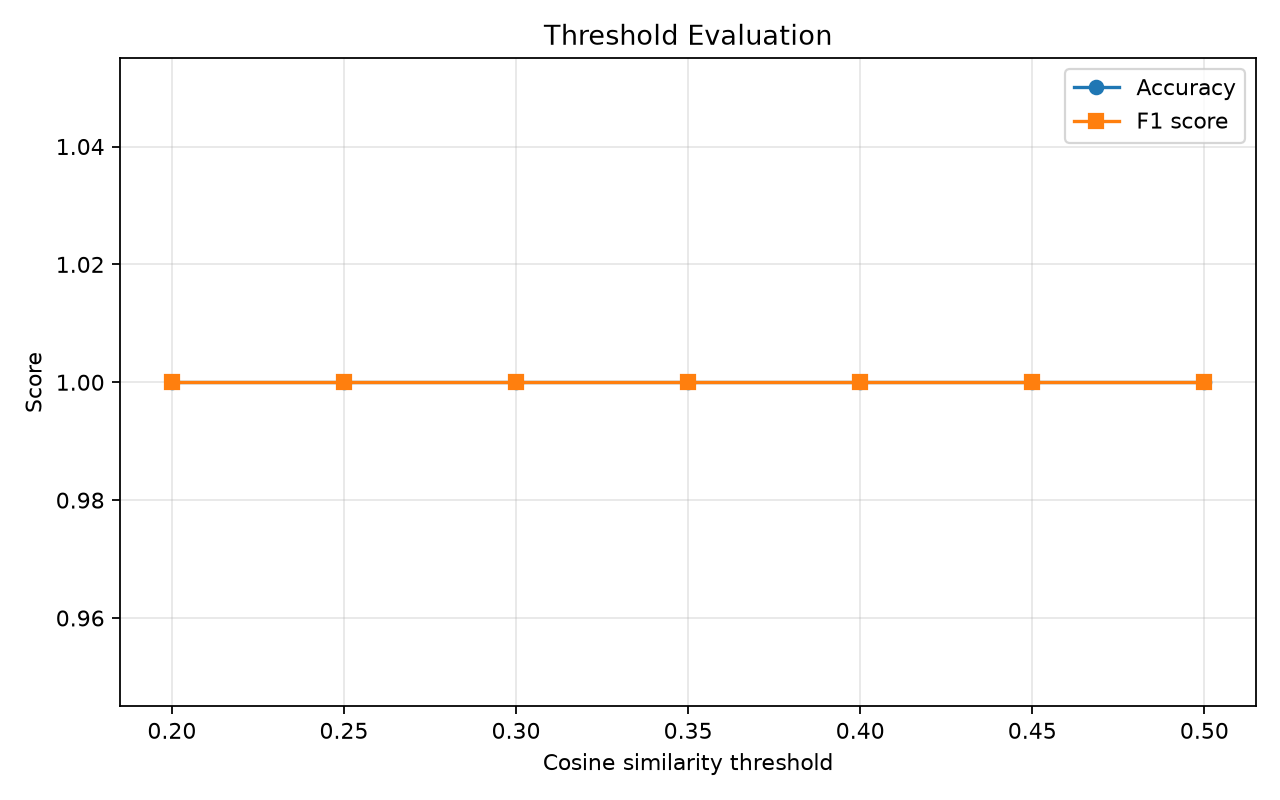

In [10]:
from pathlib import Path
from IPython.display import Image, display
from src.reporting import REPORTS_DIR
display(Image(filename=str(REPORTS_DIR / 'confusion_matrix.png')))
display(Image(filename=str(REPORTS_DIR / 'threshold_vs_accuracy.png')))